# Open two-level system with multiple observables

This example extends the minimal two-level model with radiative relaxation and pure dephasing. It demonstrates:

- GKSL collapse channels with rates stored separately from their operators;
- a stationary ground-state initial condition;
- a dissipatively broadened third-order rephasing response;
- polarization and action detection from the same third-order pathways;
- an action-population observable carrying its projection pulse;
- time-integrated radiative fluorescence after that projection pulse.

Natural units are used, with $\hbar=1$. Energies and rates are in eV, while times are in eV$^{-1}$.

In [45]:

import numpy as np
import qutip as qt
import ufss
from qudpy_fdgf import (
    EigenbasisKModel,
    ObservableSpec,
    SpectroscopyPlotter,
    SpectroscopySolver,
    translate_ufss_diagrams,
)
from qudpy_fdgf.pathways import FrequencyPathway
from qudpy_fdgf.protocols import standard_nq_protocol

## 1. Physical model

The basis is ordered as $\{|g\rangle, |e\rangle\}$. We construct the states and operators directly with QuTiP; the solver adapter converts the resulting `Qobj` instances to NumPy arrays at its numerical boundary. The Hamiltonian and transition operator are

$$
H = \omega_{eg}|e\rangle\langle e|,
\qquad
J = \mu\left(|e\rangle\langle g|+|g\rangle\langle e|\right).
$$

Radiative relaxation uses $C_{\mathrm{rad}}=|g\rangle\langle e|$. Pure dephasing uses $C_\phi=\sigma_z$. Because $\mathcal D[\sigma_z]\rho_{eg}=-2\rho_{eg}$, the collapse-channel rate is set to $\Gamma_\phi/2$ so that the optical coherence decays at the requested pure-dephasing rate $\Gamma_\phi$.

In [46]:
# Model parameters
omega_eg = 2.0
dipole_strength = 0.5
gamma_radiative = 0.04
gamma_pure_dephasing = 0.03

# States and operators in the |g>, |e> basis
ground = qt.basis(2, 0)
excited = qt.basis(2, 1)

H_site = omega_eg * excited * excited.dag()
interaction_site = dipole_strength * (
    excited * ground.dag() + ground * excited.dag()
)

ground_population_op = ground * ground.dag()
excited_population_op = excited * excited.dag()
radiative_lowering = ground * excited.dag()
dephasing_operator = qt.sigmaz()

print("QuTiP model built.")
print(f"Basis: |g>, |e>; dimension = {H_site.shape[0]}")
print(f"Transition dipole strength: {dipole_strength}")
print('ground_population_op =\n', ground_population_op)
print('excited_population_op =\n', excited_population_op)
print('radiative_lowering =\n', radiative_lowering)
print('dephasing_operator =\n', dephasing_operator)

QuTiP model built.
Basis: |g>, |e>; dimension = 2
Transition dipole strength: 0.5
ground_population_op =
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]
excited_population_op =
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0.]
 [0. 1.]]
radiative_lowering =
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 1.]
 [0. 0.]]
dephasing_operator =
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]


## 2. Build the model and solver

The physical operators are kept as QuTiP `Qobj` instances in this example. The model adapter converts them with `Qobj.full()` at the numerical boundary. `c_ops_raw` still contains `(operator, rate)` pairs: the rate must not be folded into the operator. `EigenbasisKModel` names these channels according to their input order, so `c_op_0` is radiative relaxation and `c_op_1` is pure dephasing in this example.

In [47]:
model = EigenbasisKModel(
    H_site,
    interaction_site,
    c_ops_raw=(
        (radiative_lowering, gamma_radiative),
        (dephasing_operator, gamma_pure_dephasing / 2.0),
    ),
    observable_op_arrays={
        "polarization": interaction_site,
        "ground_population": ground_population_op,
        "excited_population": excited_population_op,
    },
)

solver = SpectroscopySolver(backend="dense", eta=0.002)
solver.feed_model(model)

print(solver.summary())
print("Jump channels:", solver.jump_channel_names())
print("Memory estimate:", solver.estimate_memory())

{'backend': 'dense_liouville', 'backend_capabilities': {'pure_state': True, 'mixed_state': True, 'time_domain': True, 'frequency_domain': True, 'hilbert_resolvent': True, 'lindblad': True, 'finite_temperature': True, 'coupled_sectors': True, 'matrix_free': False, 'low_rank': False, 'metadata': {}}, 'backend_support': {'state_kinds': ('pure', 'mixed'), 'supported_pairs': (('unitary', 'time'), ('unitary', 'frequency'), ('lindblad', 'time'), ('lindblad', 'frequency')), 'exactness': 'exact', 'matrix_free': False, 'low_rank': False, 'stationary_mode_deflation': False}, 'model_requirements': {'state_kind': 'mixed', 'generator_kind': 'lindblad', 'domains': ('time', 'frequency'), 'exactness': 'exact', 'matrix_free_required': False, 'stationary_mode_deflation_required': False, 'metadata': {}}, 'model_capabilities': {'pure_state': True, 'mixed_state': False, 'time_domain': True, 'frequency_domain': False, 'hilbert_resolvent': False, 'lindblad': False, 'finite_temperature': False, 'coupled_sector

## 3. Stationary initial state

The calculation starts from the ground-state density matrix `ground_population_op`. For this zero-temperature model, the ground state is used as the field-free stationary initial condition for every pathway. No separate stationarity check is needed in this example.

## 4. Dissipatively broadened third-order rephasing response

This section shows two equivalent ways to obtain the third-order rephasing pathways. The next cell defines the pathways explicitly with `FrequencyPathway`, which makes the interaction sequence easy to read. A separate cell then asks UFSS to generate the same diagrams and translates them into `FrequencyPathway` objects. You can comment out either approach when choosing which definition to use in a calculation.

For a two-level system, the rephasing $\chi^{(3)}$ signal contains the ground-state-bleach and stimulated-emission pathways

$$R_1=(B_u,K_u,B_d),\qquad R_2=(B_u,B_d,K_u).$$

Both pathways carry the coherence history $q=(-1,0,+1)$. There is no excited-state-absorption pathway because the model contains no doubly excited manifold. Radiative relaxation contributes $\Gamma_1/2$ to the optical-coherence decay, while pure dephasing contributes $\Gamma_\phi$.

### Manual pathways generations

In [49]:
pathway_r1 = FrequencyPathway(
    name="R1",
    interactions=("Bu", "Ku", "Bd"),
    component="rephasing",
    detection="polarization",
)
pathway_r2 = FrequencyPathway(
    name="R2",
    interactions=("Bu", "Bd", "Ku"),
    component="rephasing",
    detection="polarization",
)


### Automatic pathways generation (UFSS)

In [50]:
# Generate the same third-order rephasing pathways with UFSS

phase_discrimination = [(0, 1), (1, 0), (1, 0)]
diagram_generator = ufss.DiagramGenerator()
diagram_generator.set_phase_discrimination(phase_discrimination)
diagram_generator.maximum_manifold = 1
diagram_generator.efield_times = [np.array([0.0, 0.0])] * 3
ufss_diagrams = diagram_generator.get_diagrams(np.arange(3, dtype=float))
ufss_pathways = translate_ufss_diagrams(
    ufss_diagrams,
    component="rephasing",
    names=["R1", "R2"],
    detection="polarization",
)

print("UFSS rephasing pathways:")
for pathway in ufss_pathways:
    labels = tuple(interaction.label for interaction in pathway.interactions)
    print(
        f"  {pathway.name}: {labels}, q={pathway.coherence_orders}, "
        f"prefactor={pathway.response_prefactor}"
    )

UFSS rephasing pathways:
  R1: ('Bu', 'Ku', 'Bd'), q=(-1, 0, 1), prefactor=-1j
  R2: ('Bu', 'Bd', 'Ku'), q=(-1, 0, 1), prefactor=-1j


## Calcul spectrum Generation

### Protocol and spectrum calculation

`standard_nq_protocol` describes how the solver treats the three light--matter interactions and the propagation intervals between them. Here, `n_interactions=3` specifies a third-order response. `nq_interval=1` makes the first interval the one-quantum coherence interval and assigns it to the `omega_1q` frequency axis. `detection_interval=3` assigns the third interval to the emitted-frequency axis `omega_emit`; the remaining interval, `t2`, stays in the time domain.

The arrays `omega_1q` and `omega_emit` are the frequency grids to scan. The population waiting time is not part of a pathway definition: `fixed_coordinates={"t2": population_waiting_time}` holds that time-domain coordinate fixed while the two frequency axes are scanned.

`solver.generate_spectrum` propagates the selected pathways through the model for every point on this grid, performs the requested Fourier transforms, and returns a `SpectrumResult`. The rephasing signal is then read from `rephasing_result.components["rephasing"]`.

In [51]:

protocol_1q = standard_nq_protocol(
    order=1,
    nq_interval=1,
    detection_interval=3,
    n_interactions=3,
    nq_axis="omega_1q",
    detection_axis="omega_emit",
)


omega_1q = np.linspace(-2.5, -1.5, 101)
omega_emit = np.linspace(1.5, 2.5, 101)
population_waiting_time = 10.0

rephasing_result = solver.generate_spectrum(
    protocol_1q,
    axes={"omega_1q": omega_1q, "omega_emit": omega_emit},
    fixed_coordinates={"t2": population_waiting_time},
    pathways=ufss_pathways,
)
rephasing_signal = rephasing_result.components["rephasing"]


### Plotter

`SpectroscopyPlotter` is only responsible for displaying a `SpectrumResult`; it does not recalculate the response. In the next cell, `source="components"` selects the coherent rephasing component stored in `rephasing_result`. The plotter then displays its real, imaginary, and absolute parts side by side because `view="all"`.

The constructor option `detection_phase` applies a phase rotation to the complex signal before plotting:

$$S_{\mathrm{display}} = e^{i\phi_{\mathrm{det}}} S.$$

With `detection_phase=0.0`, no rotation is applied: the real and imaginary panels show the solver's raw convention. This parameter is therefore not, by itself, a conversion from Mukamel notation to Peter Hamm notation. A difference between such conventions can sometimes be represented by a display-phase rotation, but the required sign and value depend on the Fourier-transform and response-function conventions being used. In this project, `\pi/2` is the usual candidate when the desired display is real = absorptive and imaginary = dispersive; it should be checked against a known reference spectrum. The absolute panel is unaffected by this rotation.

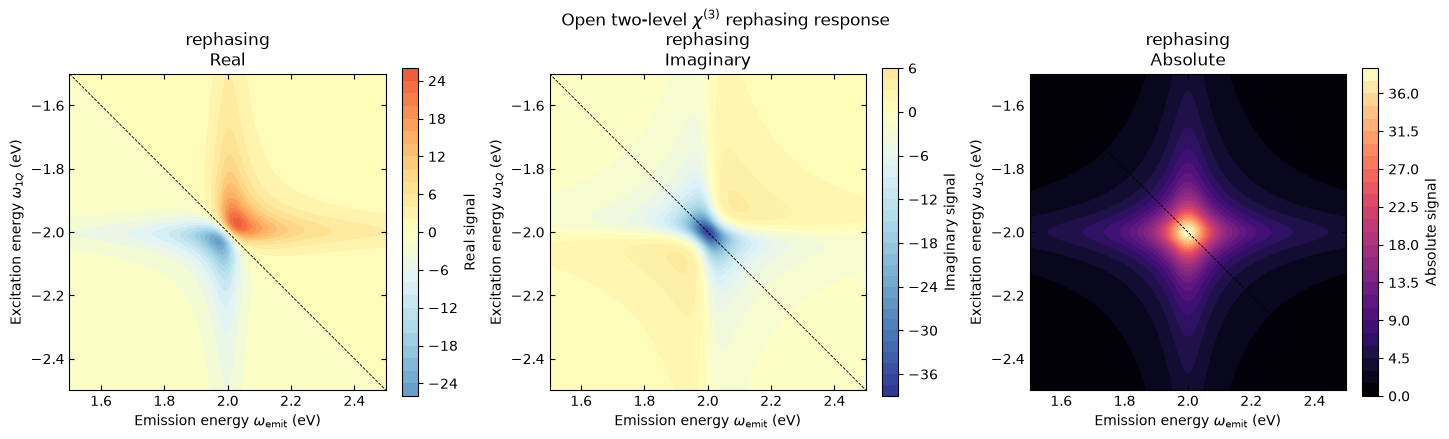

PlotResult(figure=<Figure size 1440x420 with 6 Axes>, axes=array([[<Axes: title={'center': 'rephasing\nReal'}, xlabel='Emission energy $\\omega_{\\mathrm{emit}}$ (eV)', ylabel='Excitation energy $\\omega_{1Q}$ (eV)'>,
        <Axes: title={'center': 'rephasing\nImaginary'}, xlabel='Emission energy $\\omega_{\\mathrm{emit}}$ (eV)', ylabel='Excitation energy $\\omega_{1Q}$ (eV)'>,
        <Axes: title={'center': 'rephasing\nAbsolute'}, xlabel='Emission energy $\\omega_{\\mathrm{emit}}$ (eV)', ylabel='Excitation energy $\\omega_{1Q}$ (eV)'>]],
      dtype=object), panel_names=('rephasing',), data={'rephasing': {'real': array([[-8.50078088e-02, -8.75891467e-02, -9.03123801e-02, ...,
        -1.84310980e-03, -8.84738855e-04,  0.00000000e+00],
       [-8.75891467e-02, -9.02396611e-02, -9.30356134e-02, ...,
        -9.59130035e-04,  0.00000000e+00,  8.84738855e-04],
       [-9.03123801e-02, -9.30356134e-02, -9.59080002e-02, ...,
         0.00000000e+00,  9.59130035e-04,  1.84310980e-03],
    

In [ ]:
plotter = SpectroscopyPlotter(detection_phase=0.0)
plotter.plot_spectrum_result(
    rephasing_result,
    params={
        "source": "components",
        "names": ["rephasing"],
        "view": "all",
        "normalization": "row",
        "title": r"Open two-level $\chi^{(3)}$ rephasing response",
        "labels": (
            r"Emission energy $\omega_{\mathrm{emit}}$ (eV)",
            r"Excitation energy $\omega_{1Q}$ (eV)",
        ),
        "diagonals": "auto",
        "style": {
            "cmap": "RdYlBu_r",
            "abs_cmap": "magma",
            "levels": 30,
            "contour_lines": False,
        },
        "show": True,
    },
)

## 5. Polarization and action detection from the same $\chi^{(3)}$ pathways

The solver first propagates the same three field interactions used for the third-order rephasing polarization. Polarization is contracted directly from that response, whereas each action observable carries an optional fourth interaction that projects the final optical coherence onto the population sector $q=0$. The common three-pulse response is therefore propagated only once and then reused by the coherent and action-detection branches.

For both rephasing pathways, the projection interaction is `Bu`, which changes the final order $q=+1$ to $q=0$. The pathways and protocol nevertheless remain third order: the projection pulse belongs to the observable, not to `FrequencyPathway.interactions`.

In [ ]:


pathways = (pathway_r1, pathway_r2)
'''
assert all(len(pathway.interactions) == 3 for pathway in pathways)
print("Third-order pathway coherence orders:")
for pathway in pathways:
    print(f"  {pathway.name}: {pathway.coherence_orders}")
'''


'\npathways = (pathway_r1, pathway_r2)\nassert all(len(pathway.interactions) == 3 for pathway in pathways)\nprint("Third-order pathway coherence orders:")\nfor pathway in pathways:\n    print(f"  {pathway.name}: {pathway.coherence_orders}")\n'

### Observables

`ObservableSpec` describes what is measured after the common third-order pathway propagation. The polarization observable reads the optical response directly. `ObservableSpec.action(...)` adds the fourth interaction `Bu` as a projection pulse and then measures the excited-state population. `ObservableSpec.mean_jump(...)` applies the same projection and integrates the radiative jump rate over the specified time window.

The fourth interaction belongs to the observable definition, not to `FrequencyPathway.interactions`. The pathways therefore remain third order, while the action-detection prefactor is applied to the projection step. Passing all three entries through `observables=observables` asks the solver to return polarization, action population, and action fluorescence while reusing the same propagated third-order response.

In [54]:
radiative_channel = solver.jump_channel_names()[0]
integration_window = 5.0 / gamma_radiative

observables = {
    "polarization": "polarization",
    "action_population": ObservableSpec.action(
        "action_population",
        fourth_interaction="Bu",
        operator="excited_population",
    ),
    "action_fluorescence": ObservableSpec.mean_jump(
        "action_fluorescence",
        radiative_channel,
        time_window=(0.0, integration_window),
        fourth_interaction="Bu",
    ),
}

omega_1q = np.linspace(-2.5, -1.5, 41)
omega_emit = np.linspace(1.5, 2.5, 41)
result = solver.generate_spectrum(
    protocol_1q,
    {"omega_1q": omega_1q, "omega_emit": omega_emit},
    fixed_coordinates={"t2": population_waiting_time},
    pathways=pathways,
    observables=observables,
)

## 6. Validate the three observable branches

All three signals originate from the same $\chi^{(3)}$ propagation. Only `action_population` and `action_fluorescence` apply `Bu` before detection; the fluorescence is then integrated over the finite post-projection window.

In [55]:
for pathway in pathways:
    name = pathway.name
    polarization = result.observables["polarization"][name]
    action_population = result.observables["action_population"][name]
    action_fluorescence = result.observables["action_fluorescence"][name]

    for signal in (polarization, action_population, action_fluorescence):
        assert np.all(np.isfinite(signal))
        assert np.max(np.abs(signal)) > 0.0

    print(f"{name}: max polarization = {np.max(np.abs(polarization)):.6e}")
    print(f"{name}: max action population = {np.max(np.abs(action_population)):.6e}")
    print(f"{name}: max action fluorescence = {np.max(np.abs(action_fluorescence)):.6e}")

print("Polarization and action detection use the same chi(3) pathways.")

R1: max polarization = 1.549371e+01
R1: max action population = 1.549371e+01
R1: max action fluorescence = 1.539252e+01
R2: max polarization = 2.311391e+01
R2: max action population = 2.311391e+01
R2: max action fluorescence = 2.296295e+01
Polarization and action detection use the same chi(3) pathways.


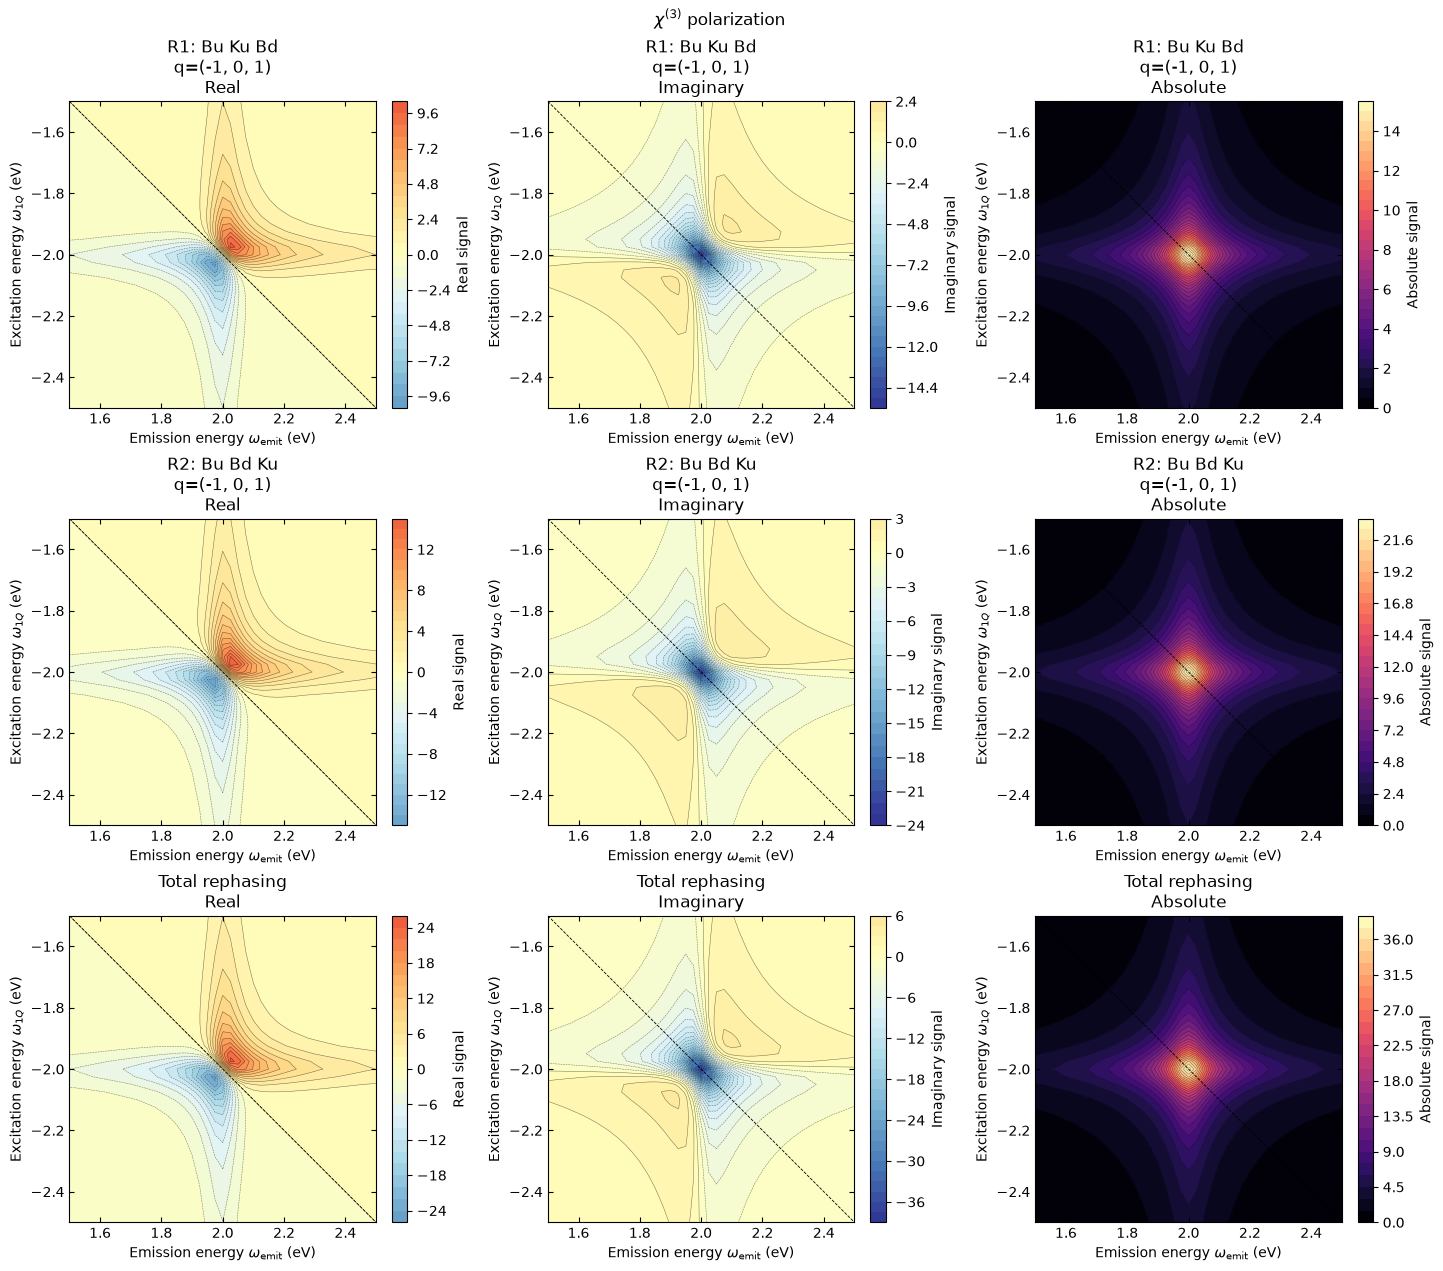

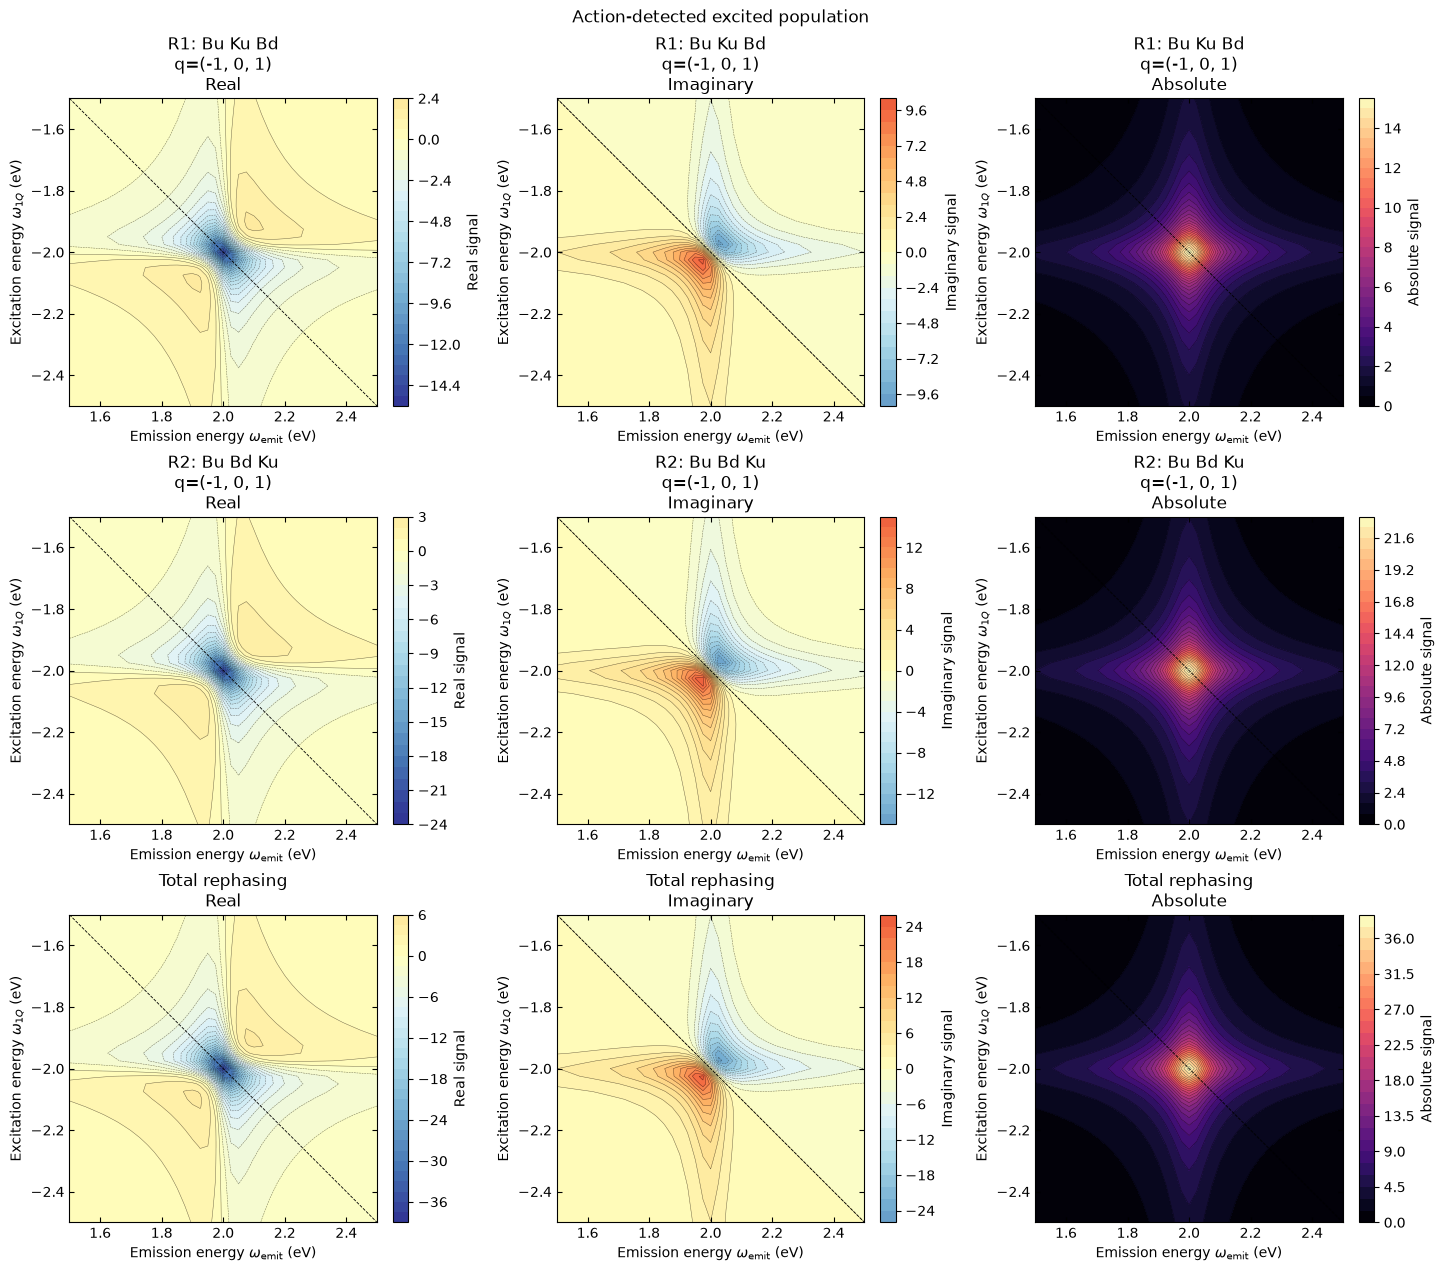

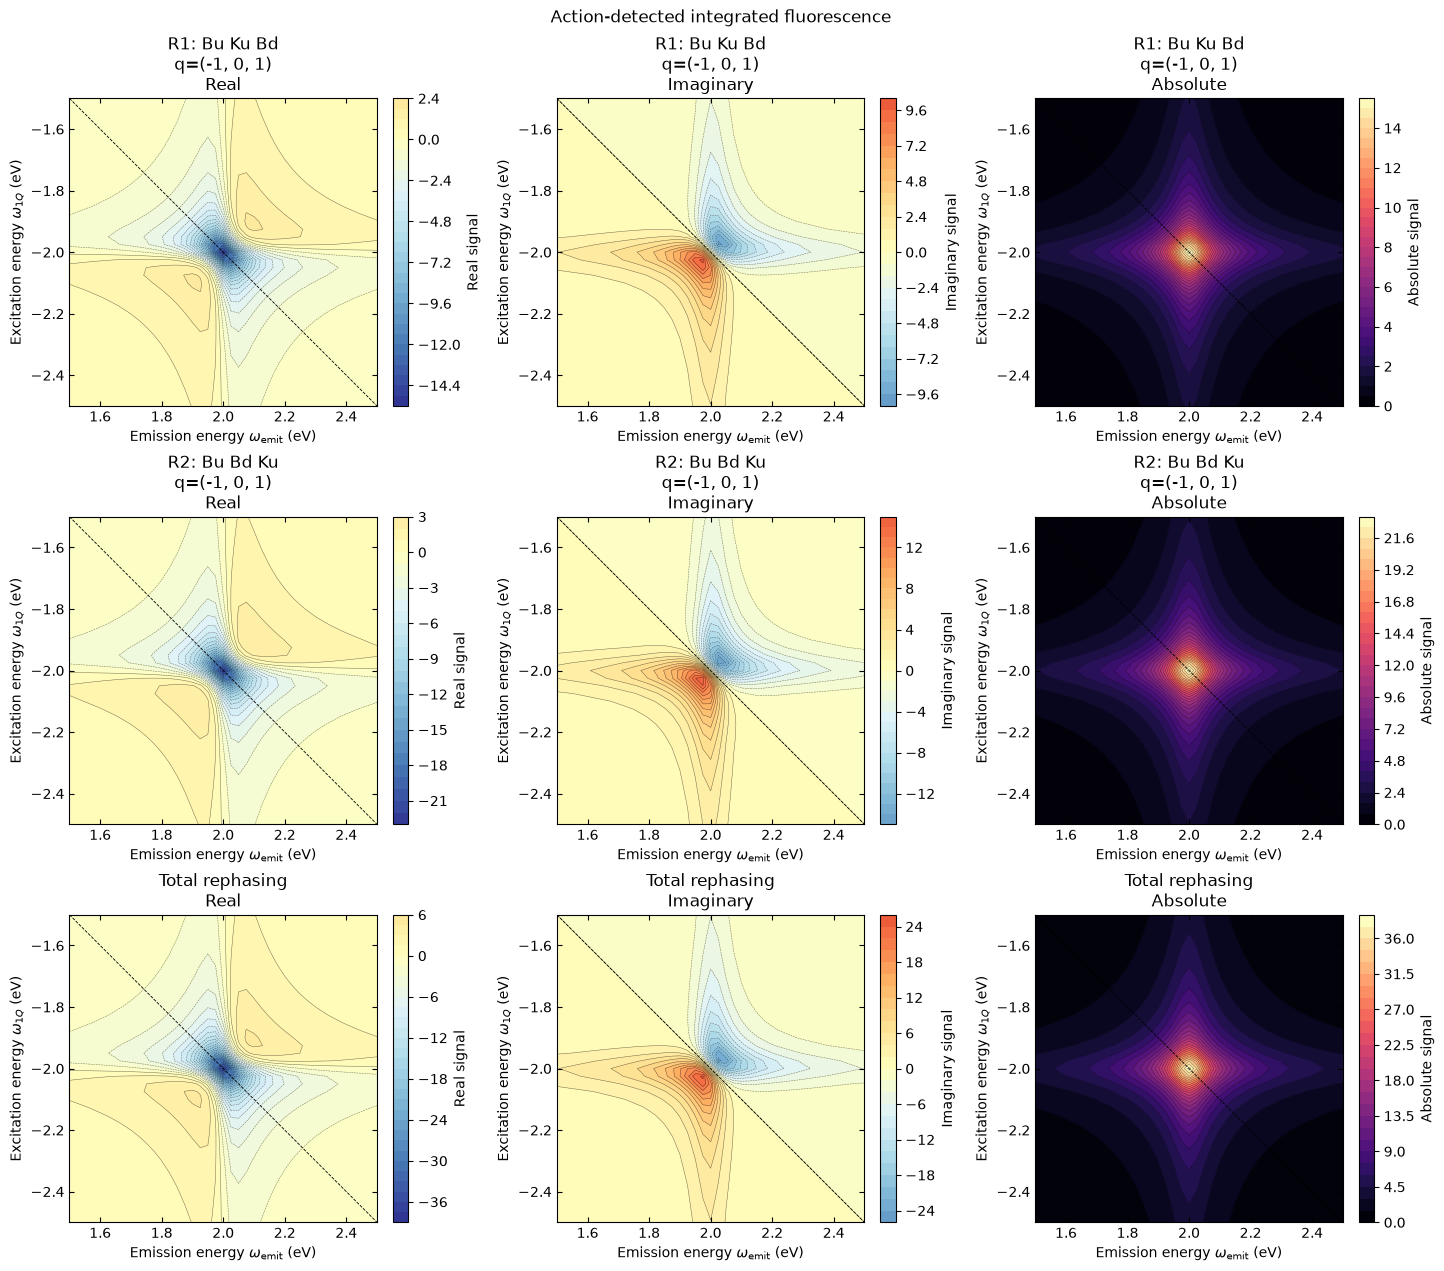

In [56]:
for observable_name, title in (
    ("polarization", r"$\chi^{(3)}$ polarization"),
    ("action_population", "Action-detected excited population"),
    ("action_fluorescence", "Action-detected integrated fluorescence"),
):
    plotter.plot_spectrum_result(
        result,
        params={
            "source": "observables",
            "observable": observable_name,
            "pathways": ["R1", "R2"],
            "view": "all",
            "normalization": "row",
            "title": title,
            "labels": (
                r"Emission energy $\omega_{\mathrm{emit}}$ (eV)",
                r"Excitation energy $\omega_{1Q}$ (eV)",
            ),
            "diagonals": "auto",
            "show": True,
        },
    )

## What this example shows

1. Collapse operators and rates are supplied separately.
2. The ground state is stationary under the field-free GKSL generator.
3. Radiative relaxation and pure dephasing broaden a third-order rephasing spectrum.
4. Action observables carry the `Bu` projection pulse while every pathway remains third order.
5. One spectrum calculation returns polarization, action population, and integrated action fluorescence from the same propagated response.